In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [ ]:
import pandas as pd

baseline = pd.read_csv("../results/baseline_image_results.csv")
iegef = pd.read_csv("../results/iegef_image_results.csv")

In [3]:
if torch.backends.mps.is_available():
    device = torch.device("mps")

elif torch.cuda.is_available():
    device = torch.device("cuda")

else:
    device = torch.device("cpu")

print(device)

mps


In [4]:
IMAGENET_MEAN = np.array([0.485,0.456,0.406])
IMAGENET_STD = np.array([0.229,0.224,0.225])

def denormalize_image(tensor):

    image = tensor.cpu().numpy()

    image = np.transpose(image,(1,2,0))

    image = image * IMAGENET_STD + IMAGENET_MEAN

    image = np.clip(image,0,1)

    return image.astype(np.float32)

In [5]:
dataset_path="../datasets/COVID-19_Radiography_Dataset"

_,_,test_loader,*_=create_dataloaders(

    dataset_path=dataset_path,

    batch_size=1,

    load_masks=True
)

In [6]:
baseline_model=build_resnet50()

baseline_model=load_checkpoint(

    baseline_model,

    "../checkpoints/best_resnet50.pth",

    device
)

baseline_model.to(device)

baseline_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [7]:
iegef_model=build_resnet50()

iegef_model=load_checkpoint(

    iegef_model,

    "../checkpoints/best_iegef_resnet50.pth",

    device
)

iegef_model.to(device)

iegef_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [8]:
sample_index=25

In [9]:
sample=list(test_loader)[sample_index]

image,mask,label=sample

image=image.to(device)

In [10]:
target_layers=[baseline_model.layer4[-1]]

baseline_gc=generate_gradcam(

    baseline_model,

    image,

    target_layers,

    target_class=label.item()

)

baseline_gcpp=generate_gradcam_plus_plus(

    baseline_model,

    image,

    target_layers,

    target_class=label.item()

)

baseline_ig=generate_integrated_gradients(

    baseline_model,

    image,

    target_class=label.item()

)

In [11]:
target_layers=[iegef_model.layer4[-1]]

iegef_gc=generate_gradcam(

    iegef_model,

    image,

    target_layers,

    target_class=label.item()

)

iegef_gcpp=generate_gradcam_plus_plus(

    iegef_model,

    image,

    target_layers,

    target_class=label.item()

)

iegef_ig=generate_integrated_gradients(

    iegef_model,

    image,

    target_class=label.item()

)

In [12]:
original_rgb=denormalize_image(image.squeeze())

original_gray=np.mean(original_rgb,axis=2)

lung_mask=mask.squeeze().cpu().numpy()

baseline_gc_overlay=overlay_heatmap(
    original_rgb,
    baseline_gc
)

baseline_gcpp_overlay=overlay_heatmap(
    original_rgb,
    baseline_gcpp
)

baseline_ig_overlay=overlay_heatmap(
    original_rgb,
    baseline_ig
)

iegef_gc_overlay=overlay_heatmap(
    original_rgb,
    iegef_gc
)

iegef_gcpp_overlay=overlay_heatmap(
    original_rgb,
    iegef_gcpp
)

iegef_ig_overlay=overlay_heatmap(
    original_rgb,
    iegef_ig
)

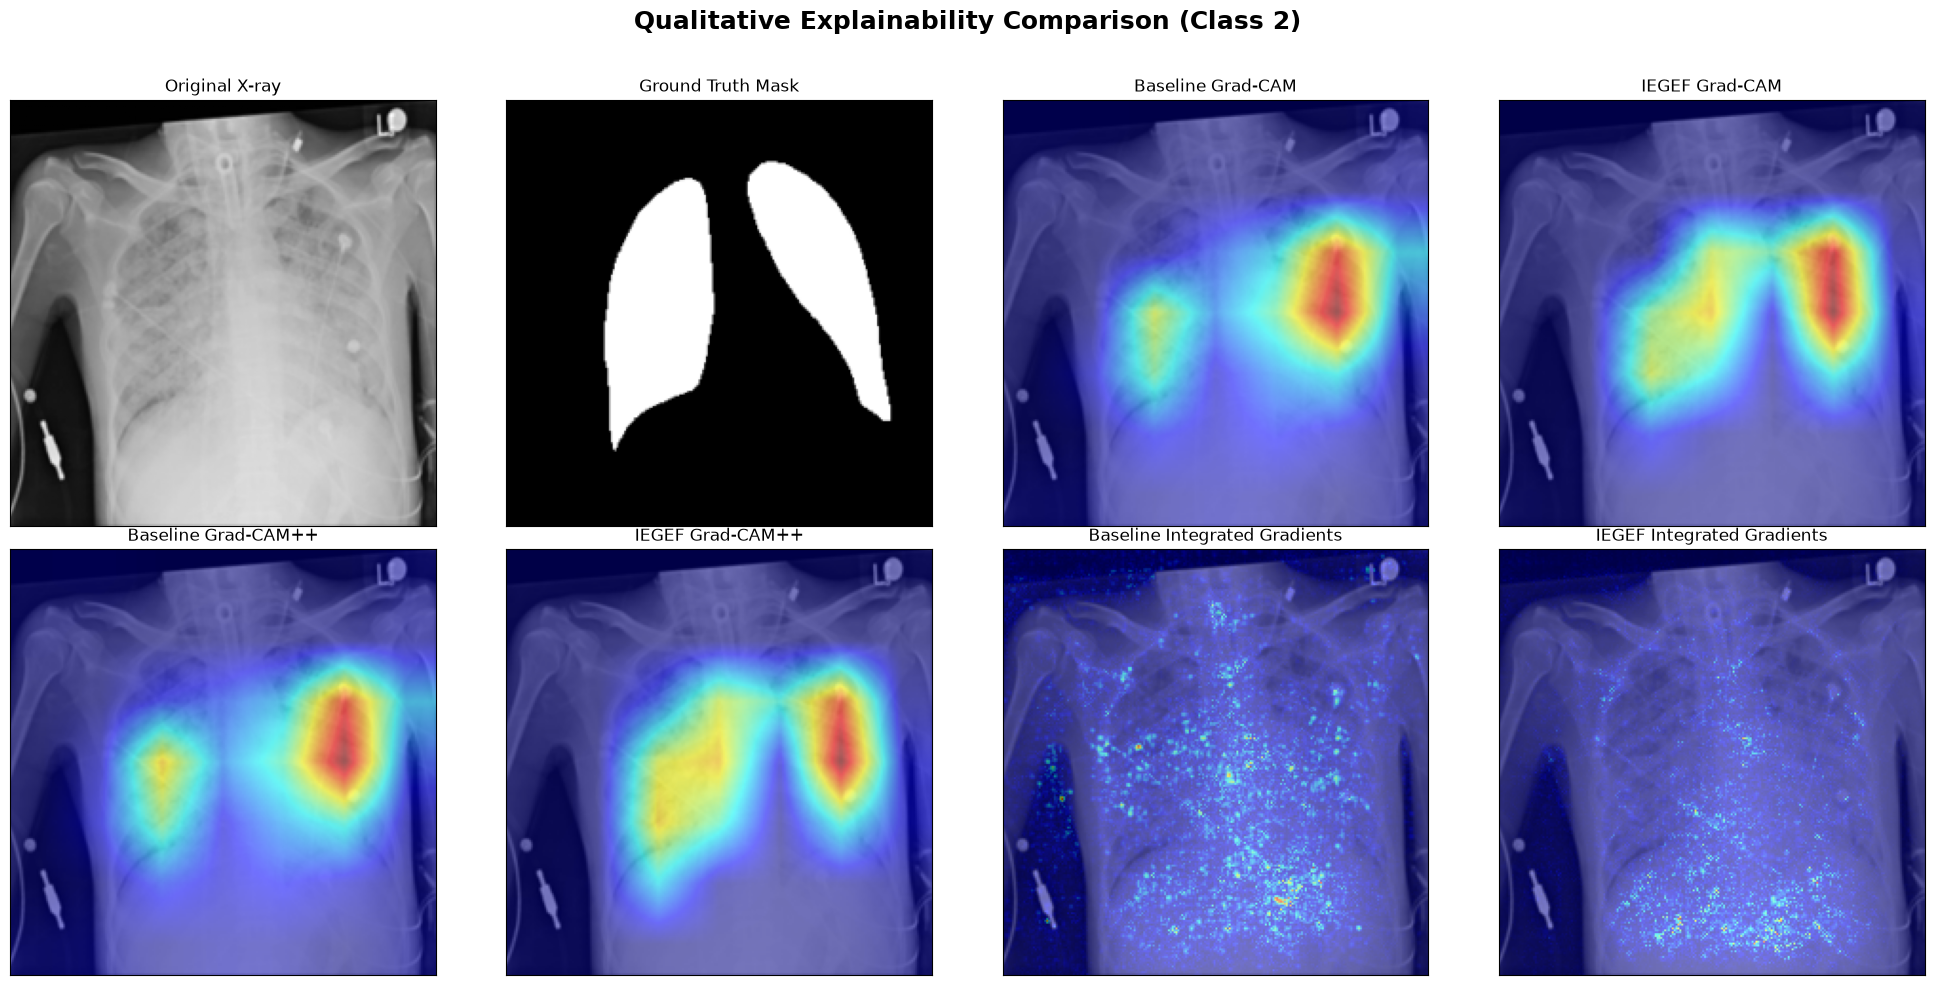

In [13]:
fig,ax=plt.subplots(

    2,

    4,

    figsize=(20,10)

)

ax[0,0].imshow(original_gray,cmap="gray")
ax[0,0].set_title("Original X-ray")

ax[0,1].imshow(lung_mask,cmap="gray")
ax[0,1].set_title("Ground Truth Mask")

ax[0,2].imshow(baseline_gc_overlay)
ax[0,2].set_title("Baseline Grad-CAM")

ax[0,3].imshow(iegef_gc_overlay)
ax[0,3].set_title("IEGEF Grad-CAM")

ax[1,0].imshow(baseline_gcpp_overlay)
ax[1,0].set_title("Baseline Grad-CAM++")

ax[1,1].imshow(iegef_gcpp_overlay)
ax[1,1].set_title("IEGEF Grad-CAM++")

ax[1,2].imshow(baseline_ig_overlay)
ax[1,2].set_title("Baseline Integrated Gradients")

ax[1,3].imshow(iegef_ig_overlay)
ax[1,3].set_title("IEGEF Integrated Gradients")

for a in ax.ravel():

    a.set_xticks([])

    a.set_yticks([])

plt.suptitle(

    f"Qualitative Explainability Comparison (Class {label.item()})",

    fontsize=18,

    fontweight="bold"

)

plt.tight_layout(rect=[0,0,1,0.96])

plt.savefig(

    "../results/qualitative_sample.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [14]:
samples=[5,25,120,500]

In [15]:
for sample_index in samples:

    sample=list(test_loader)[sample_index]

    image,mask,label=sample

    print(

        "Sample:",sample_index,

        "Class:",label.item()

    )

Sample: 5 Class: 1
Sample: 25 Class: 2
Sample: 120 Class: 2
Sample: 500 Class: 1


In [16]:
print("""

Figure X.

Qualitative comparison between the baseline ResNet50 and the
proposed IEGEF framework.

For the same chest X-ray, IEGEF produces more localized and
clinically meaningful Grad-CAM and Grad-CAM++ activation maps,
which better align with the annotated lung regions. Integrated
Gradients exhibits comparatively diffuse attributions, consistent
with the quantitative evaluation presented in Chapter 5.

""")



Figure X.

Qualitative comparison between the baseline ResNet50 and the
proposed IEGEF framework.

For the same chest X-ray, IEGEF produces more localized and
clinically meaningful Grad-CAM and Grad-CAM++ activation maps,
which better align with the annotated lung regions. Integrated
Gradients exhibits comparatively diffuse attributions, consistent
with the quantitative evaluation presented in Chapter 5.


